<a href="https://colab.research.google.com/github/sabbirpuspo/LearningforMe/blob/main/Heart_Dataset_PK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [4]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/SkillMorph Datasets/heart.csv')
print(f"Shape: {df.shape}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (303, 14)


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
import os

drive_path = '/content/drive/MyDrive/SkillMorph Datasets/'
if os.path.exists(drive_path):
    print(f"Contents of '{drive_path}':")
    for item in os.listdir(drive_path):
        print(item)
else:
    print(f"The directory '{drive_path}' does not exist or is not accessible.")

Contents of '/content/drive/MyDrive/SkillMorph Datasets/':
diabetes.csv
StudentsPerformance.csv
gym_membership.csv
Housing.csv
cybersecurity_intrusion_data.csv
dataset_with_all_features v2.csv
heart.csv


In [7]:

missing = df.isnull().sum()
print("Missing values per column:\n", missing[missing > 0])
print("\nTarget Variable Labels (Output Column):\n", df['output'].value_counts().sort_index())
print("\nNote: The 'output' column is binary (0 or 1)")


Missing values per column:
 Series([], dtype: int64)

Target Variable Labels (Output Column):
 output
0    138
1    165
Name: count, dtype: int64

Note: The 'output' column is binary (0 or 1)


In [9]:
# Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# Create a copy of the DataFrame for processing
df_processed = df.copy()

# Separate features (X) and target (y)
X = df_processed.drop(columns=['output'])
y = df_processed['output']

# Identify categorical columns for one-hot encoding
categorical_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Scale the features
X_scaled = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=20,stratify=y)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 242 | Test: 61


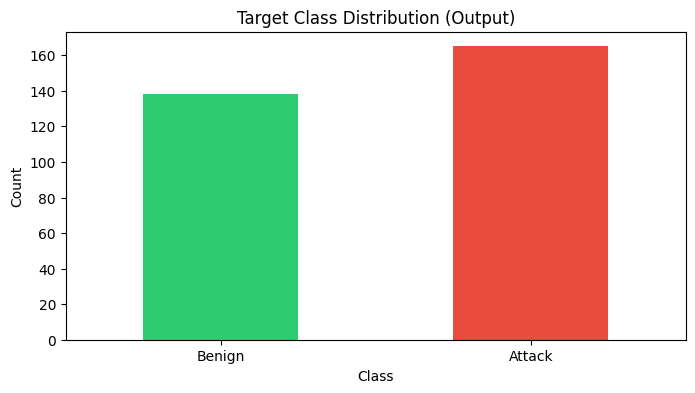

In [11]:
labels = ['Benign', 'Attack'] # Changed to reflect binary target

counts = df['output'].value_counts().sort_index() # Changed 'attack_detected' to 'output'

fig, ax = plt.subplots(figsize=(8, 4))

counts.plot.bar(
    ax=ax,
    color=['#2ecc71', '#e74c3c'] # Adjusted colors for two classes
)

ax.set_xticklabels(labels, rotation=0)
ax.set_title('Target Class Distribution (Output)') # Updated title to reflect 'output' column
ax.set_xlabel('Class')
ax.set_ylabel('Count')

plt.show()

In [12]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=20),
    'KNN (k=5)':     KNeighborsClassifier(n_neighbors=5),
    'Logistic Reg':  LogisticRegression(max_iter=1000, random_state=20)
}
results, predictions = {}, {}

for name, m in models.items():
    m.fit(X_train, y_train)
    yp = m.predict(X_test)
    predictions[name] = yp
    results[name] = {
        'Accuracy':  accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp, average='weighted'),
        'Recall':    recall_score(y_test, yp, average='weighted'),
        'F1-Score':  f1_score(y_test, yp, average='weighted')
    }
    print(f"{name}: Acc={results[name]['Accuracy']:.4f}  Precision = {results[name]['Precision']:.4f} Recall = {results[name]['Recall']:.4f} F1={results[name]['F1-Score']:.4f}")


Decision Tree: Acc=0.8197  Precision = 0.8242 Recall = 0.8197 F1=0.8200
KNN (k=5): Acc=0.8361  Precision = 0.8361 Recall = 0.8361 F1=0.8361
Logistic Reg: Acc=0.8689  Precision = 0.8698 Recall = 0.8689 F1=0.8684


           Accuracy  Precision  Recall  F1-Score
max_depth                                       
3            0.8197     0.8242  0.8197    0.8200
5            0.8033     0.8056  0.8033    0.8036
10           0.8197     0.8242  0.8197    0.8200
15           0.8197     0.8242  0.8197    0.8200
20           0.8197     0.8242  0.8197    0.8200
None         0.8197     0.8242  0.8197    0.8200


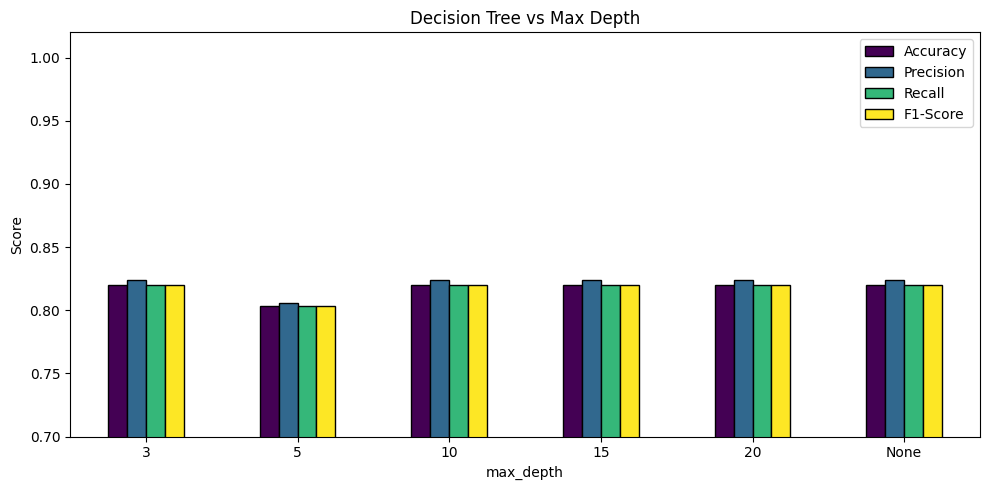

In [13]:
dt_results = []
for d in [3, 5, 10, 15, 20, None]:
    dt = DecisionTreeClassifier(max_depth=d, random_state=20).fit(X_train, y_train)
    yp = dt.predict(X_test)
    dt_results.append({'max_depth': str(d) or 'None',
        'Accuracy': accuracy_score(y_test, yp), 'Precision': precision_score(y_test, yp, average='weighted'),
        'Recall': recall_score(y_test, yp, average='weighted'), 'F1-Score': f1_score(y_test, yp, average='weighted')})

dt_df = pd.DataFrame(dt_results).set_index('max_depth')
print(dt_df.round(4))
dt_df.plot(kind='bar', figsize=(10,5), colormap='viridis', edgecolor='black')
plt.title('Decision Tree vs Max Depth'); plt.ylabel('Score'); plt.ylim(0.7, 1.02); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

In [14]:
target_names = ['Benign', 'Attack'] # Changed to match the 2 classes (0 and 1) in attack_detected
for name, yp in predictions.items():
    print(f"\n{'='*55}\n{name}\n{'='*55}")
    print(classification_report(y_test, yp, target_names=target_names, digits=4))


Decision Tree
              precision    recall  f1-score   support

      Benign     0.7742    0.8571    0.8136        28
      Attack     0.8667    0.7879    0.8254        33

    accuracy                         0.8197        61
   macro avg     0.8204    0.8225    0.8195        61
weighted avg     0.8242    0.8197    0.8200        61


KNN (k=5)
              precision    recall  f1-score   support

      Benign     0.8214    0.8214    0.8214        28
      Attack     0.8485    0.8485    0.8485        33

    accuracy                         0.8361        61
   macro avg     0.8350    0.8350    0.8350        61
weighted avg     0.8361    0.8361    0.8361        61


Logistic Reg
              precision    recall  f1-score   support

      Benign     0.8846    0.8214    0.8519        28
      Attack     0.8571    0.9091    0.8824        33

    accuracy                         0.8689        61
   macro avg     0.8709    0.8653    0.8671        61
weighted avg     0.8698    0.8689 

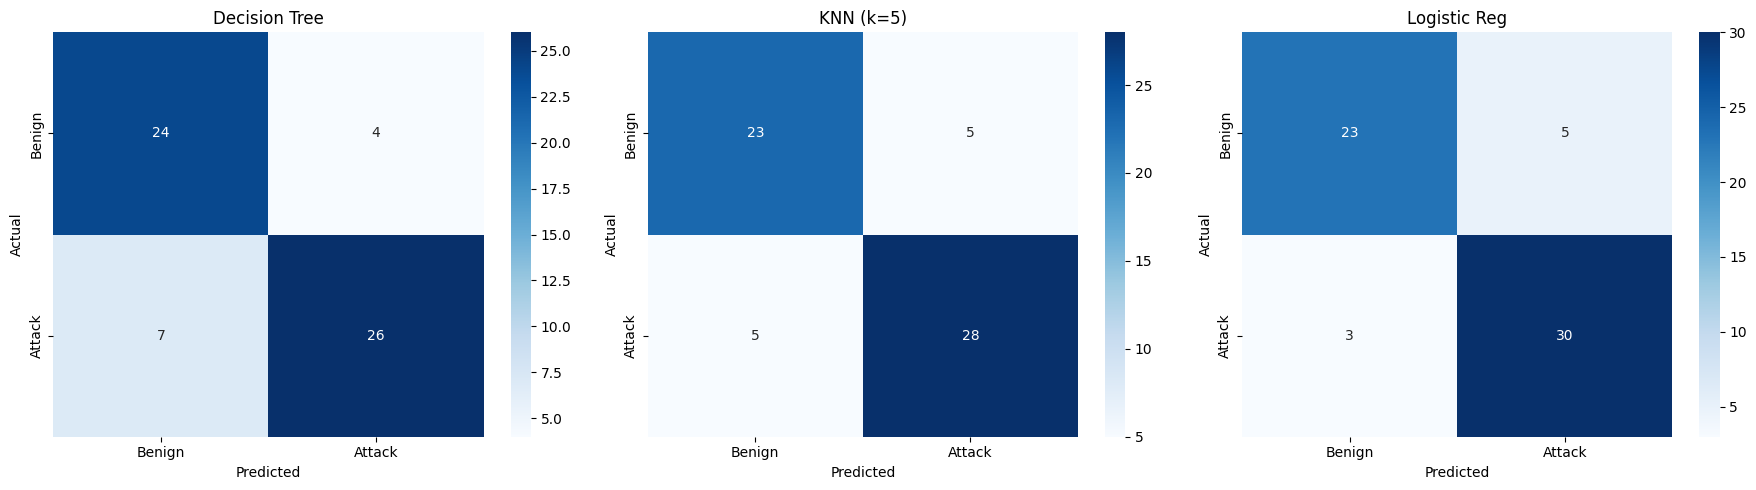

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, yp) in zip(axes, predictions.items()):
    sns.heatmap(confusion_matrix(y_test, yp), annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=target_names, yticklabels=target_names)
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

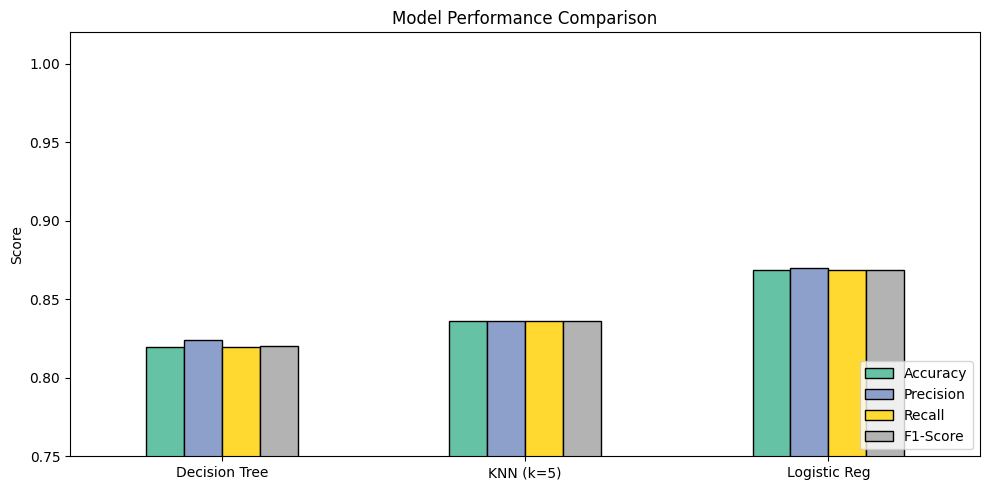


Summary:
                Accuracy  Precision  Recall  F1-Score
Decision Tree    0.8197     0.8242  0.8197    0.8200
KNN (k=5)        0.8361     0.8361  0.8361    0.8361
Logistic Reg     0.8689     0.8698  0.8689    0.8684


In [16]:
res_df = pd.DataFrame(results).T
res_df.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black')
plt.title('Model Performance Comparison'); plt.ylabel('Score'); plt.ylim(0.75, 1.02)
plt.xticks(rotation=0); plt.legend(loc='lower right'); plt.tight_layout(); plt.show()
print("\nSummary:\n", res_df.round(4))